# 📊 MLP Model Training - Hierarchical Demand Forecasting

## 🔍 Въведение
Този notebook е посветен на обучението на Multi-Layer Perceptron (MLP) модел за прогнозиране на продажби. Моделът използва обработените данни от DataProcessing.ipynb и следва архитектурата, специално разработена за таблични данни с lag features, rolling statistics и календарни характеристики.

---

## 🎯 Цел
Изграждане и обучение на MLP модел за regression задача (прогнозиране на продажби 1 ден напред), който:
✅ Използва обработените данни от DataProcessing pipeline
✅ Следва оптимална архитектура за таблични данни
✅ Включва Batch Normalization и Dropout за стабилност и regularization
✅ Имплементира early stopping за предотвратяване на overfitting
✅ Използва подходящи метрики за regression (MSE, MAE, RMSE)

---

## 📋 План на notebook-а

| Секция | Описание |
|--------|----------|
| **0. Setup** | Импортиране на библиотеки, настройка на пътища |
| **1. Load Processed Data** | Зареждане на X_train_scaled, y_train и т.н. |
| **2. Model Architecture** | Дефиниране на MLP архитектурата |
| **3. Compile Model** | Конфигуриране на optimizer, loss и metrics |
| **4. Training** | Обучение с validation и early stopping |
| **5. Evaluation** | Оценка на модела върху test set |
| **6. Save Model** | Запазване на обучения модел |

---


## 0. Setup


In [21]:
import torch
import os
os.environ["KERAS_BACKEND"] = "torch"

from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import json

from sklearn.metrics import mean_squared_error, mean_absolute_error
import keras
from keras import layers, callbacks

# Проектови пътища
# Определяне на root директорията (работи независимо от текущата директория)
if Path.cwd().name == "models":
    PROJ_ROOT = Path.cwd().resolve().parent
else:
    PROJ_ROOT = Path.cwd().resolve()

DATA_PROCESSED = PROJ_ROOT / "data" 
MODELS_DIR = PROJ_ROOT / "models"
DATA_DIR = PROJ_ROOT / "data"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Проверка за GPU
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# Seed за възпроизводимост
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

print(f"\n✅ Setup завършен")
print(f"Keras backend: {keras.config.backend()}")


CUDA available: False

✅ Setup завършен
Keras backend: torch


## 1. Load Processed Data

Зареждаме обработените данни от DataProcessing pipeline.

**Как да заредите данните:**

1. **Препоръчителен метод:** Изпълнете DataProcessing.ipynb (секции 0-9) - той автоматично запазва данните в `data/processed/processed_data.pkl`
2. Клетката по-долу автоматично зарежда данните от файла (по-бързо и надеждно)
3. **Алтернативен метод:** Ако файлът не съществува, опитва се да използва `%run` magic

След зареждане ще имате в паметта:
- `X_train_scaled`, `y_train`
- `X_val_scaled`, `y_val`  
- `X_test_scaled`, `y_test`


In [22]:
processed_data_path = DATA_PROCESSED / "processed_data.pkl"

if processed_data_path.exists():
    print(f"📂 Зареждане на данни от файл: {processed_data_path}")
    with open(processed_data_path, "rb") as f:
        data = pickle.load(f)
    
    X_train_scaled = data["X_train_scaled"]
    y_train = data["y_train"]
    X_val_scaled = data["X_val_scaled"]
    y_val = data["y_val"]
    X_test_scaled = data["X_test_scaled"]
    y_test = data["y_test"]
    
    print("✅ Данните са заредени от файл!")
else:
    print(f"⚠️  Файлът {processed_data_path} не съществува")
    print("\n💡 Решение:")
    print("   1. Изпълнете DataProcessing.ipynb (секции 0-9) за да създадете файла")
    print("   2. Или използвайте %run magic по-долу (ако е наличен)")
    
    # Алтернативен метод: %run magic
    try:
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython is not None:
            print("\n🔄 Опит за зареждане чрез %run magic...")
            ipython.run_line_magic('run', '../data/DataProcessing.ipynb')
            print("✅ Данните са заредени чрез %run magic")
        else:
            raise NameError("Not running in IPython environment")
    except (NameError, ModuleNotFoundError, AttributeError) as e:
        print(f"\n❌ %run magic не е наличен: {e}")
        raise ValueError("Няма налични данни! Изпълнете DataProcessing.ipynb първо.")


📂 Зареждане на данни от файл: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/data/processed_data.pkl
✅ Данните са заредени от файл!


In [23]:
# Проверка на заредените данни
print("📊 Проверка на данните...\n")

try:
    # Проверяваме дали данните са в паметта
    X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test
    
    print("✅ Данните са успешно заредени!\n")
    
    # Размери на данните
    print(f"📊 Данни за обучение:")
    print(f"   X_train_scaled: {X_train_scaled.shape}")
    print(f"   y_train: {y_train.shape}")
    print(f"\n📊 Данни за валидация:")
    print(f"   X_val_scaled: {X_val_scaled.shape}")
    print(f"   y_val: {y_val.shape}")
    print(f"\n📊 Данни за тестване:")
    print(f"   X_test_scaled: {X_test_scaled.shape}")
    print(f"   y_test: {y_test.shape}")
    
except NameError as e:
    print(f"❌ Данните не са заредени: {e}")
    print("\n💡 Решение:")
    print("   1. Изпълнете DataProcessing.ipynb (секции 0-9) за да създадете processed_data.pkl")
    print("   2. Или използвайте %run magic в клетката по-горе")
    raise


📊 Проверка на данните...

✅ Данните са успешно заредени!

📊 Данни за обучение:
   X_train_scaled: (755405, 36)
   y_train: (755405,)

📊 Данни за валидация:
   X_val_scaled: (161590, 36)
   y_val: (161590,)

📊 Данни за тестване:
   X_test_scaled: (162155, 36)
   y_test: (162155,)


In [24]:
# Подготовка на данните за обучение

# Брой на features
n_features = X_train_scaled.shape[1]
print(f"✅ Брой features: {n_features}")

# Конвертиране към numpy arrays (ако са pandas DataFrames)
if isinstance(X_train_scaled, pd.DataFrame):
    X_train_scaled = X_train_scaled.values
    X_val_scaled = X_val_scaled.values
    X_test_scaled = X_test_scaled.values

if isinstance(y_train, pd.Series):
    y_train = y_train.values
    y_val = y_val.values
    y_test = y_test.values

# Конвертиране към float32 за по-добра производителност
X_train_scaled = X_train_scaled.astype("float32")
X_val_scaled = X_val_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")
y_train = y_train.astype("float32")
y_val = y_val.astype("float32")
y_test = y_test.astype("float32")

print(f"\n✅ Данните са готови за обучение (float32)")
print(f"   Train: {len(X_train_scaled):,} редове")
print(f"   Val:   {len(X_val_scaled):,} редове")
print(f"   Test:  {len(X_test_scaled):,} редове")


✅ Брой features: 36

✅ Данните са готови за обучение (float32)
   Train: 755,405 редове
   Val:   161,590 редове
   Test:  162,155 редове


## **2. Model Architecture**

### **➤ 1. Input Layer**
- Размерът = броя на входните признаци (features)
- В нашия случай: **input_dim=22** (22 features)

### **➤ 2. Hidden Layers**
Архитектура: **256 → 128 → 64 → 32** (по-дълбока пирамида)
- Dense(256, ReLU) + BatchNorm + Dropout(0.4) + L2(1e-4)
- Dense(128, ReLU) + BatchNorm + Dropout(0.3) + L2(1e-4)
- Dense(64, ReLU) + BatchNorm + Dropout(0.2) + L2(1e-4)
- Dense(32, ReLU) + BatchNorm + Dropout(0.1) + L2(1e-4)

### **➤ 3. Output Layer**
- 1 неврон (прогноза за продажби)
- Активация: **linear** (regression задача)

---


In [25]:
from keras import regularizers

model = keras.Sequential(
    [
        # Input layer - по-голям първи слой
        layers.Dense(
            256, 
            activation="relu", 
            input_shape=(n_features,), 
            name="dense_1",
            kernel_regularizer=regularizers.L2(1e-4)  # L2 regularization
        ),
        layers.BatchNormalization(name="bn_1"),
        layers.Dropout(0.4, name="dropout_1"),  # По-силен dropout
        
        # Hidden layer 2
        layers.Dense(
            128, 
            activation="relu", 
            name="dense_2",
            kernel_regularizer=regularizers.L2(1e-4)
        ),
        layers.BatchNormalization(name="bn_2"),
        layers.Dropout(0.3, name="dropout_2"),
        
        # Hidden layer 3
        layers.Dense(
            64, 
            activation="relu", 
            name="dense_3",
            kernel_regularizer=regularizers.L2(1e-4)
        ),
        layers.BatchNormalization(name="bn_3"),
        layers.Dropout(0.2, name="dropout_3"),
        
        # Hidden layer 4
        layers.Dense(
            32, 
            activation="relu", 
            name="dense_4",
            kernel_regularizer=regularizers.L2(1e-4)
        ),
        layers.BatchNormalization(name="bn_4"),
        layers.Dropout(0.1, name="dropout_4"),
        
        # Output layer
        layers.Dense(1, activation="linear", name="output"),
    ],
    name="MLP_Demand_Forecasting_Improved"
)

# Показване на архитектурата
print("📊 Model Architecture:")
model.summary()

# Показване на броя параметри
total_params = model.count_params()

try:
    # За PyTorch backend, използваме numel() за всеки weight
    trainable_params = sum(w.numel() if hasattr(w, 'numel') else int(np.prod(w.shape)) for w in model.trainable_weights)
except:
    # Fallback: в повечето случаи всички параметри са trainable
    trainable_params = total_params

print(f"\n📈 Параметри:")
print(f"   Общо: {total_params:,}")
print(f"   Trainable: {trainable_params:,}")


/Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


📊 Model Architecture:


Model: "MLP_Demand_Forecasting_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,657 (213.50 KB)

 Trainable params: 53,697 (209.75 KB)

 Non-trainable params: 960 (3.75 KB)


📈 Параметри:
   Общо: 54,657
   Trainable: 53,697


## 3. Compile Model

**Optimizer:** Adam с learning rate = 0.0005 и Cosine Decay schedule

**Loss:** Mean Squared Error (MSE) - стандартна за regression

**Metrics:** MSE, MAE, RMSE

**Регуларизация:**
- L2 kernel regularization (1e-4) на всички Dense слоеве
- Dropout: 0.4 → 0.3 → 0.2 → 0.1 (намалява се с дълбочината)


In [26]:
def root_mean_squared_error(y_true, y_pred):
    return keras.ops.sqrt(keras.ops.mean(keras.ops.square(y_pred - y_true)))

# Компилиране на модела с оптимизиран learning rate
from keras.optimizers import Adam

# Learning rate ще се управлява от Cosine Decay в callbacks
initial_lr = 0.0005
optimizer = Adam(learning_rate=initial_lr)  # По-нисък learning rate за по-стабилно обучение

model.compile(
    optimizer=optimizer,
    loss="mse", 
    metrics=[
        "mse", 
        "mae", 
        root_mean_squared_error, 
    ],
)

print("✅ Моделът е компилиран")
print(f"   Optimizer: Adam (lr=0.0005)")
print(f"   Loss: MSE (Mean Squared Error)")
print(f"   Metrics: MSE, MAE, RMSE")


✅ Моделът е компилиран
   Optimizer: Adam (lr=0.0005)
   Loss: MSE (Mean Squared Error)
   Metrics: MSE, MAE, RMSE


## 4. Training

Обучение с:
- **Early Stopping** - спира при липса на подобрение върху validation set
- **Model Checkpoint** - запазва най-добрия модел
- **Cosine Decay** - автоматично намалява learning rate (вградено в optimizer)
- **Validation split** - използваме отделен validation set


In [ ]:
callbacks_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,  
        restore_best_weights=True,  # Връща най-добрите тежести
        verbose=1,
    ),
    
    # Model checkpoint - запазва най-добрия модел
    callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / "best_mlp_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    
    # Забележка: Learning rate се управлява от Cosine Decay schedule в optimizer-а
    # ReduceLROnPlateau не може да се използва заедно с schedule
]

# Параметри за обучение
BATCH_SIZE = 1024
EPOCHS = 100

# Проверка за initial_lr (ако не е дефиниран в секция 3)
try:
    initial_lr
except NameError:
    initial_lr = 0.0005  # Default learning rate

# Cosine Decay за learning rate schedule
from keras.optimizers.schedules import CosineDecay

decay_steps = EPOCHS * (len(X_train_scaled) // BATCH_SIZE)  # Общ брой стъпки
cosine_decay = CosineDecay(
    initial_learning_rate=initial_lr,
    decay_steps=decay_steps,
    alpha=0.0  # Минимален learning rate (0% от началния)
)

# Обновяване на optimizer с Cosine Decay
optimizer = Adam(learning_rate=cosine_decay)
model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mse", "mae", root_mean_squared_error],
)

print(f"🚀 Започване на обучение...")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Max epochs: {EPOCHS}")
print(f"   Initial learning rate: {initial_lr}")
print(f"   Learning rate schedule: Cosine Decay")
print(f"   Early stopping: patience=10")
print(f"   Model checkpoint: {MODELS_DIR / 'best_mlp_model.keras'}")

# Обучение на модела
history = model.fit(
    X_train_scaled,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_scaled, y_val),
    callbacks=callbacks_list,
    verbose=1,
)

print("\n✅ Обучението завърши!")


🚀 Започване на обучение...
   Batch size: 1024
   Max epochs: 100
   Initial learning rate: 0.0005
   Learning rate schedule: Cosine Decay
   Early stopping: patience=10
   Model checkpoint: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/best_mlp_model.keras
Epoch 1/100
738/738 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.8697 - mae: 1.1073 - mse: 7.8361 - root_mean_squared_error: 3.0614
Epoch 1: val_loss improved from None to 5.47714, saving model to /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/best_mlp_model.keras
738/738 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 6.6747 - mae: 1.0032 - mse: 6.6418 - root_mean_squared_error: 3.1277 - val_loss: 5.4771 - val_mae: 0.8679 - val_mse: 5.4448 - val_root_mean_squared_error: 2.0385 - learning_rate: 4.9988e-04
Epoch 2/100
737/738 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.6778 - mae: 0.8847 - mse: 5.6456 - root_mean_squared_e

TypeError: This optimizer was created with a `LearningRateSchedule` object as its `learning_rate` constructor argument, hence its learning rate is not settable. If you need the learning rate to be settable, you should instantiate the optimizer with a float `learning_rate` argument.

## 5. Evaluation

Оценка на модела върху test set с подходящи метрики за regression.


In [ ]:
# Прогнози върху test set
print("📊 Оценка върху test set...")
y_pred = model.predict(X_test_scaled, batch_size=BATCH_SIZE, verbose=1)
y_pred = y_pred.flatten()  # Преобразуване към 1D array

# Изчисляване на метрики
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Допълнителни метрики
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100  # Mean Absolute Percentage Error

print(f"\n📈 Метрики върху test set:")
print(f"   MSE:  {mse:.4f}")
print(f"   MAE:  {mae:.4f}")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAPE: {mape:.2f}%")

# Сравнение на train и validation loss от history
if history:
    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]
    
    print(f"\n📊 Final loss:")
    print(f"   Train: {final_train_loss:.4f}")
    print(f"   Val:   {final_val_loss:.4f}")
    print(f"   Test:  {mse:.4f}")
    
    # Проверка за overfitting
    if final_val_loss > final_train_loss * 1.2:
        print(f"\n⚠️  Възможно overfitting (val_loss > train_loss * 1.2)")
    else:
        print(f"\n✅ Няма признаци за overfitting")


📊 Оценка върху test set...
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

📈 Метрики върху test set:
   MSE:  5.1130
   MAE:  0.9345
   RMSE: 2.2612
   MAPE: 3400647936.00%

📊 Final loss:
   Train: 5.3074
   Val:   4.9767
   Test:  5.1130

✅ Няма признаци за overfitting


### 5.1. Training History Visualization

Визуализация на learning curves за анализ на обучението.


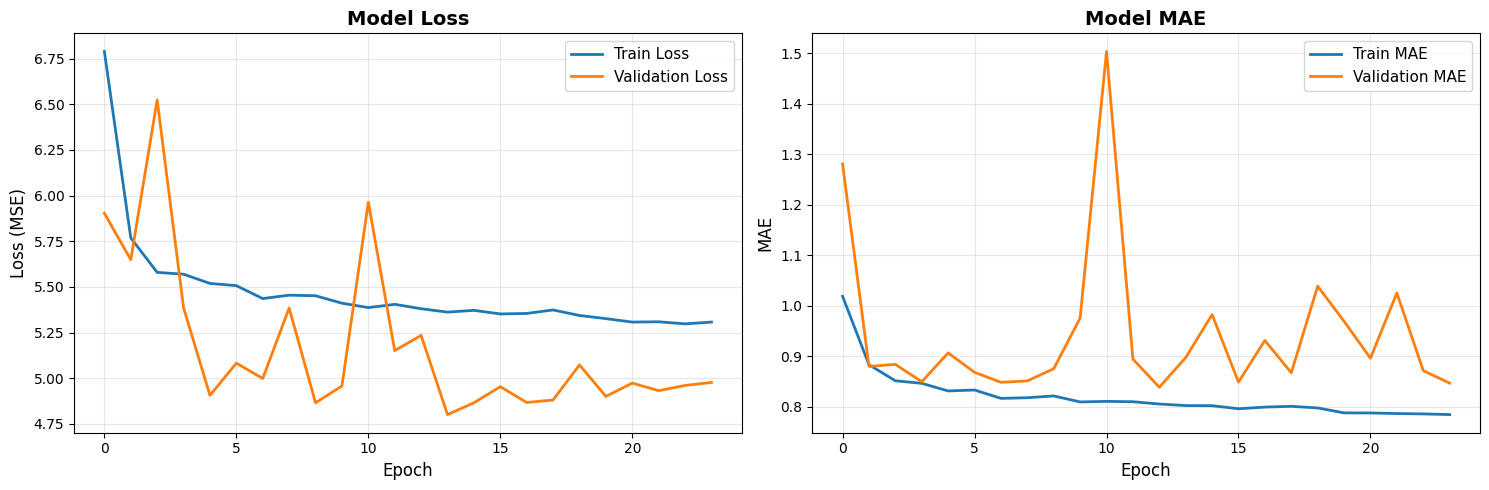

✅ Training history визуализация запазена: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/training_history.png


In [ ]:
import matplotlib.pyplot as plt

if history:
    # Създаване на фигура с две подграфи
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss curves
    axes[0].plot(history.history["loss"], label="Train Loss", linewidth=2)
    axes[0].plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
    axes[0].set_title("Model Loss", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Epoch", fontsize=12)
    axes[0].set_ylabel("Loss (MSE)", fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # MAE curves
    if "mae" in history.history:
        axes[1].plot(history.history["mae"], label="Train MAE", linewidth=2)
        axes[1].plot(history.history["val_mae"], label="Validation MAE", linewidth=2)
        axes[1].set_title("Model MAE", fontsize=14, fontweight="bold")
        axes[1].set_xlabel("Epoch", fontsize=12)
        axes[1].set_ylabel("MAE", fontsize=12)
        axes[1].legend(fontsize=11)
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Запазване на фигурата
    fig.savefig(MODELS_DIR / "training_history.png", dpi=300, bbox_inches="tight")
    print(f"✅ Training history визуализация запазена: {MODELS_DIR / 'training_history.png'}")
